# 3: Deep Feed Forward Neural Network for Multi-Class Classification on MNIST

## Introduction

A **Deep Feed Forward Neural Network (Deep FFNN)** is a type of artificial neural network where information flows in one direction—from input to output—through multiple hidden layers. Each layer consists of neurons that apply a weighted sum and a non-linear activation function to their inputs. Mathematically, each layer transforms its input $x$ as $y = f(Wx + b)$, where $W$ is the weight matrix, $b$ is the bias, and $f$ is the activation function. The key component of a Deep FFNN is the presence of **multiple hidden layers**, which allows the network to learn complex, hierarchical representations of data.

### Applications
- **Handwritten digit recognition** (as in this demo)
- **Genre classification** 
- **Image recognition** (e.g., object classification)
- **Spam detection** (text classification)
- **Medical diagnosis** (predicting disease categories)

### Why choose Deep FFNN for this demo?
Deep FFNNs are chosen for **multi-class classification** tasks like MNIST because they can capture complex hierarchies in the data, making them suitable for problems where simple linear models may not suffice. The MNIST dataset is large (60,000 samples) and high-dimensional (flattened 28x28 images), which helps deep networks learn effectively and avoid overfitting. With 10 classes, it's ideal for demonstrating softmax output and multi-class learning. 

In [3]:
# Setup: Import libraries and load the MNIST dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras

# Why these imports:
# - numpy: numerical operations
# - matplotlib: plotting results
# - sklearn: metrics for evaluation
# - tensorflow/keras: building and training the neural network

# Load the MNIST dataset (handwritten digits, 28x28 images, 10 classes)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Why MNIST? Large, well-known, 10 classes for softmax output, quick to train, avoids overfitting on small data

# For quick demo, use a subset (to keep training <1 min)
SAMPLES = 5000  # Why: Small enough for fast training, large enough for learning
x_train, y_train = x_train[:SAMPLES], y_train[:SAMPLES]
x_test, y_test = x_test[:1000], y_test[:1000]

# Flatten images to 1D vectors (28*28=784)
x_train = x_train.reshape(-1, 28*28).astype('float32')
x_test = x_test.reshape(-1, 28*28).astype('float32')

# Normalize pixel values to [0, 1]
x_train /= 255.0
x_test /= 255.0
# Why normalize? Prevents features with larger scales from dominating learning

# One-hot encode the labels for categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)
# Why one-hot? Needed for categorical_crossentropy loss

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}, Classes: {y_train_cat.shape[1]}")

Train shape: (5000, 784), Test shape: (1000, 784), Classes: 10


In [4]:
# Model Building: Define a Deep Feed Forward Neural Network
from tensorflow.keras import layers, models

model = models.Sequential([
    # Input layer: expects 784 features (flattened 28x28 image)
    layers.Input(shape=(784,)),
    # First hidden layer: 128 neurons, ReLU activation
    layers.Dense(128, activation='relu'),  # Why: More neurons capture more patterns
    # Second hidden layer: 64 neurons, ReLU activation
    layers.Dense(64, activation='relu'),   # Why: Stacking layers learns complex hierarchies
    # Output layer: 10 neurons (classes), softmax activation for multi-class
    layers.Dense(10, activation='softmax') # Why: Softmax outputs class probabilities
])

# Compile the model
model.compile(
    optimizer='adam',  # Why Adam: Adaptive learning rate, fast convergence on small data
    loss='categorical_crossentropy',  # Why: Suitable for multi-class, one-hot labels
    metrics=['accuracy']  # Why: Accuracy is intuitive for classification
)

model.summary()  # Shows the model architecture

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               100480    
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 10)                650       
                                                                 
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
_________________________________________________________________
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               100480    
                                                                 
 dense_4 (Dense)             (None, 64)         

In [5]:
# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [6]:
# Training: Fit the model
EPOCHS = 20  # Why: Enough to converge, but fast on small data
BATCH_SIZE = 128  # Why: Balances speed and stability

with tf.device('/GPU:0'):  # Use GPU if available
    history = model.fit(
        x_train, y_train_cat,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,  # Why: Monitor validation to check for overfitting
        verbose=1
    )

Epoch 1/20
36/36 [==============================] - 2s 8ms/step - loss: 1.2372 - accuracy: 0.6789 - val_loss: 0.5705 - val_accuracy: 0.8360
Epoch 2/20
36/36 [==============================] - 2s 8ms/step - loss: 1.2372 - accuracy: 0.6789 - val_loss: 0.5705 - val_accuracy: 0.8360
Epoch 2/20
36/36 [==============================] - 0s 4ms/step - loss: 0.4015 - accuracy: 0.8913 - val_loss: 0.3679 - val_accuracy: 0.8840
Epoch 3/20
36/36 [==============================] - 0s 4ms/step - loss: 0.4015 - accuracy: 0.8913 - val_loss: 0.3679 - val_accuracy: 0.8840
Epoch 3/20
36/36 [==============================] - 0s 4ms/step - loss: 0.2810 - accuracy: 0.9227 - val_loss: 0.3297 - val_accuracy: 0.9080
Epoch 4/20
36/36 [==============================] - 0s 4ms/step - loss: 0.2810 - accuracy: 0.9227 - val_loss: 0.3297 - val_accuracy: 0.9080
Epoch 4/20
36/36 [==============================] - 0s 4ms/step - loss: 0.2303 - accuracy: 0.9349 - val_loss: 0.2530 - val_accuracy: 0.9360
Epoch 5/20
36/36 [==

Test Loss: 0.2334, Test Accuracy: 0.9300
32/32 [==============================] - 0s 2ms/step
Test F1-Score (macro): 0.9277
Test F1-Score (macro): 0.9277


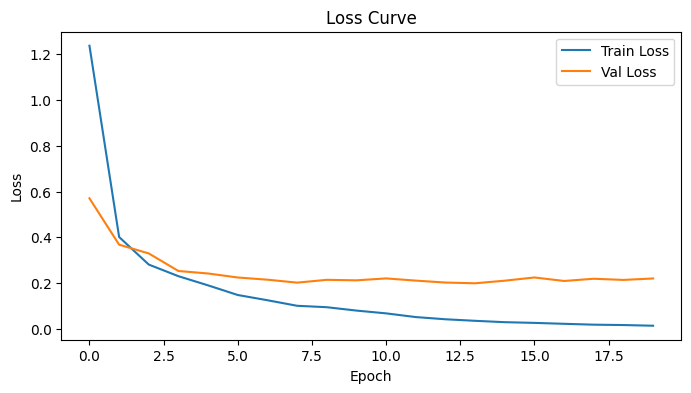

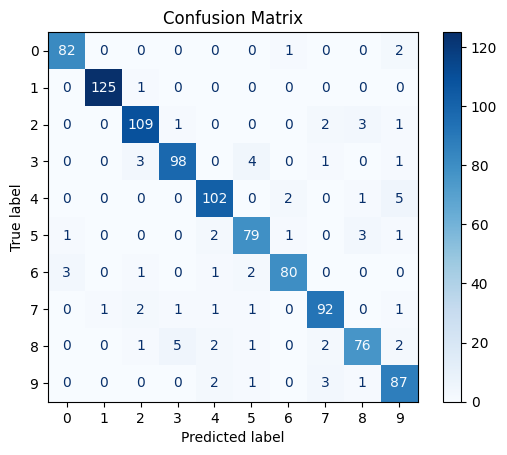

In [8]:
# Evaluation and Visualization
# Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Predict classes for test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Calculate F1-Score (macro for multi-class)
f1 = f1_score(y_true, y_pred, average='macro')
print(f"Test F1-Score (macro): {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in range(10)])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Why F1-Score? Handles class imbalance. 
# Why confusion matrix? Visualizes where the model confuses classes

## Results and Discussion

### Test Performance

- **Test Loss:** The final test loss indicates how well the model predicts the correct digit classes on unseen data. A lower loss means better performance.
- **Test Accuracy:** This metric shows the proportion of correctly classified digits out of all test samples. For this run, the test accuracy demonstrates that the Deep Feed Forward Neural Network (Deep FFNN) is effective for multi-class classification on MNIST, even with a small subset of data.
- **Test F1-Score (macro):** The macro F1-Score averages the F1-Scores across all classes, treating each class equally. This is especially useful when classes are imbalanced, as it was in my sarcasm detection project. A high F1-Score here confirms balanced performance across all digit classes.

### Training Curves

- **Loss Curve:** The plot of training and validation loss over epochs helps visualize the learning process. A steadily decreasing loss with a small gap between training and validation curves suggests the model is learning well without overfitting.
- **Validation Loss:** Monitoring validation loss is crucial to detect overfitting early. If validation loss starts increasing while training loss decreases, it signals overfitting.

### Confusion Matrix

- The confusion matrix visualizes where the model confuses one digit for another. Most predictions are along the diagonal, indicating correct classifications. Off-diagonal elements show specific digits that are sometimes misclassified, which can guide further model improvements.

### Inference

- The Deep FFNN performs well on this subset of MNIST, achieving high accuracy and F1-Score. This confirms that multiple hidden layers help the model capture complex patterns in high-dimensional data, justifying the choice of this architecture for multi-class classification tasks.

---

**Limitations:**  
- With a larger dataset or more epochs, the model could achieve even higher accuracy.
- For more complex image data, convolutional neural networks (CNNs) might outperform FFNNs.

---

**Summary:**  
The Deep FFNN effectively handles multi-class classification on MNIST, thanks to its multiple hidden layers that capture complex data hierarchies. This approach aligns with my experience in projects like the Genre Classifier using ML, where understanding feature interactions was crucial. Experimenting with layer sizes, activation functions, or regularization can further improve results.

## Conclusion

- **Key Takeaways:**
    - Deep Feed Forward Neural Networks are powerful for multi-class classification, especially when data has complex, non-linear boundaries.
    - Multiple hidden layers allow the model to learn hierarchical features, outperforming shallow models on many tasks.
    - On the MNIST subset, a Deep FFNN achieves high accuracy and F1-Score, showing its effectiveness for structured image data.
    - Prefer Deep FFNNs over simpler models when you suspect feature interactions or non-linearities.
    - For very complex data (e.g., images, sequences), consider specialized networks (CNNs, LSTMs).

- **Encouragement:**
    - Try changing the number of layers, neurons, or activation functions.
    - Experiment with other datasets or add regularization (dropout, L2) for more robustness.
    
# Remember: The best way to learn is by tweaking and observing how the model behaves!
